# 01: Exploratory Data Analysis

Understand FX rate patterns, volatility characteristics, and data quality for Kenya (KES) and Azerbaijan (AZN).


In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1] / "src"))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from collectors.cbk_collector import CBKCollector
from collectors.cba_collector import CBACollector
from engine.regime_engine import RegimeEngine
from config import MARKETS

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Setup complete
Analysis date: 2026-03-11 02:50


## 1. Load Historical FX Data

In [5]:
cbk = CBKCollector()
cba = CBACollector()

end_date = datetime.now()
start_date = end_date - timedelta(days=730)

print(f"Fetching data from {start_date.date()} to {end_date.date()}")

kes_data = cbk.get_rates(currency='USD', start_date=start_date, end_date=end_date)
# azn_data = cba.get_historical_rates(start_date=start_date, end_date=end_date, currency='USD')

print(f"KES/USD: {len(kes_data)} records")
# print(f"AZN/USD: {len(azn_data)} records")


INFO:collectors.cbk_collector:Fetching CBK webpage for USD...


Fetching data from 2024-03-11 to 2026-03-11


INFO:collectors.cbk_collector:Returning sample KES data for testing


KES/USD: 30 records


## 2. Data Quality Assessment

In [7]:
def assess_quality(df, date_col, rate_col, name):
    report = {
        'market': name,
        'records': len(df),
        'missing': df[rate_col].isna().sum(),
        'mean': df[rate_col].mean(),
        'std': df[rate_col].std(),
        'min': df[rate_col].min(),
        'max': df[rate_col].max()
    }
    return report

kes_q = assess_quality(kes_data, 'date', 'kes_per_usd', 'Kenya')
print("Kenya (KES):", kes_q)

# if not azn_data.empty:
#     azn_q = assess_quality(azn_data.reset_index(), 'date', 'azn_per_unit', 'Azerbaijan')
#     print("Azerbaijan (AZN):", azn_q)


Kenya (KES): {'market': 'Kenya', 'records': 30, 'missing': np.int64(0), 'mean': np.float64(133.47380952380954), 'std': np.float64(1.780127549745097), 'min': np.float64(130.0), 'max': np.float64(136.98571428571427)}


## 3. Visualize FX Rate History

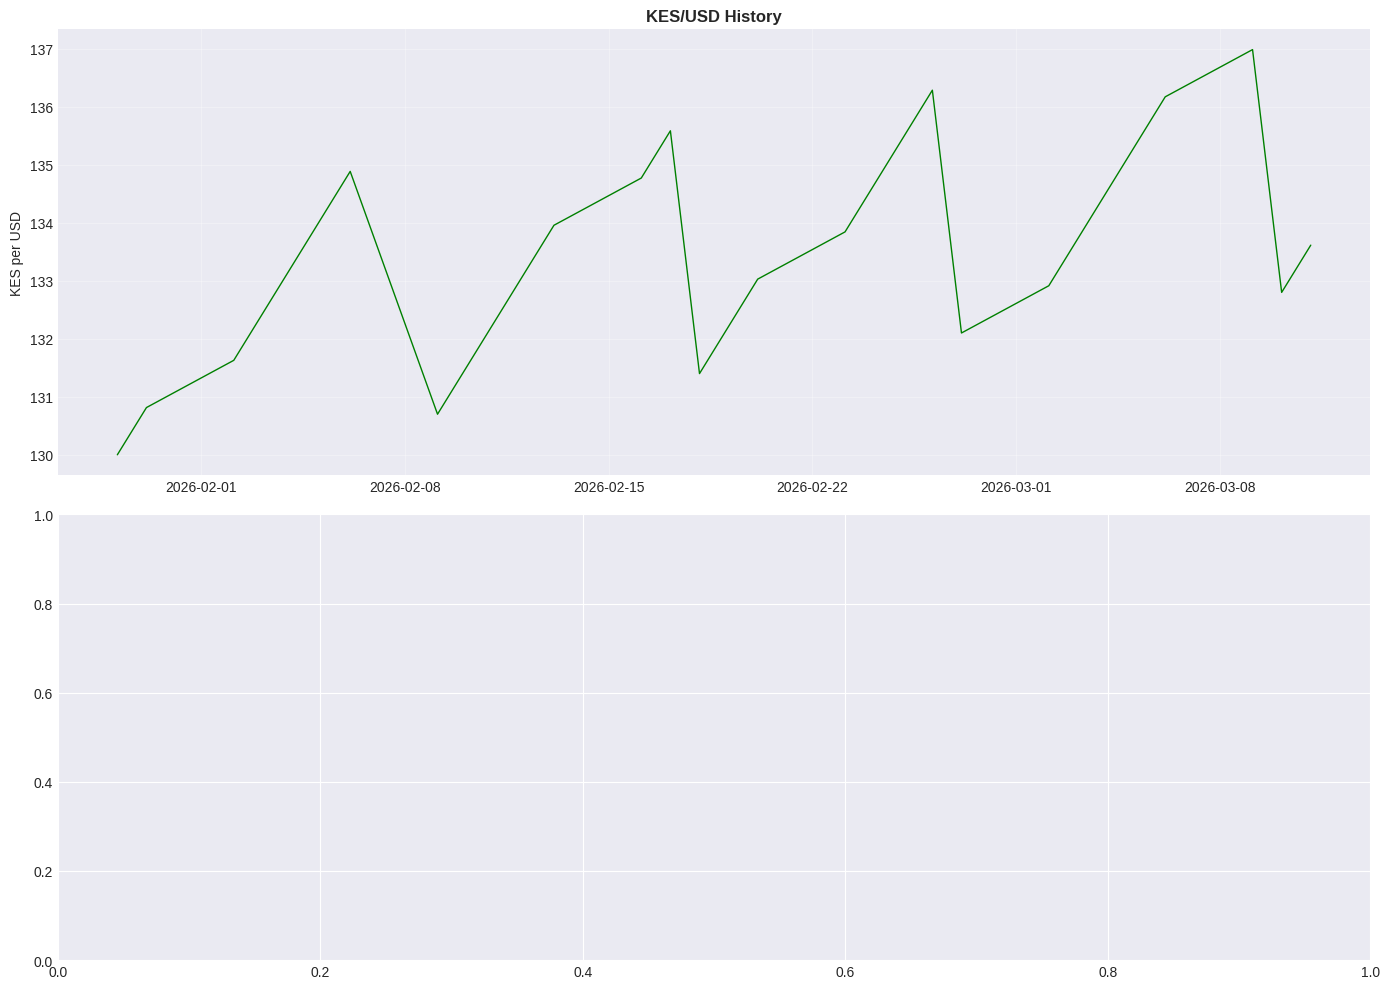

Saved: eda_fx_history.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

if not kes_data.empty:
    axes[0].plot(pd.to_datetime(kes_data['date']), kes_data['kes_per_usd'], 
                 color='green', linewidth=1)
    axes[0].set_title('KES/USD History', fontweight='bold')
    axes[0].set_ylabel('KES per USD')
    axes[0].grid(True, alpha=0.3)

# if not azn_data.empty:
#     axes[1].plot(azn_data.index, azn_data['azn_per_unit'], 
#                  color='blue', linewidth=1)
#     axes[1].set_title('AZN/USD History', fontweight='bold')
#     axes[1].set_ylabel('AZN per USD')
#     axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/eda_fx_history.png', dpi=150)
plt.show()
print("Saved: eda_fx_history.png")


## 4. Returns Distribution

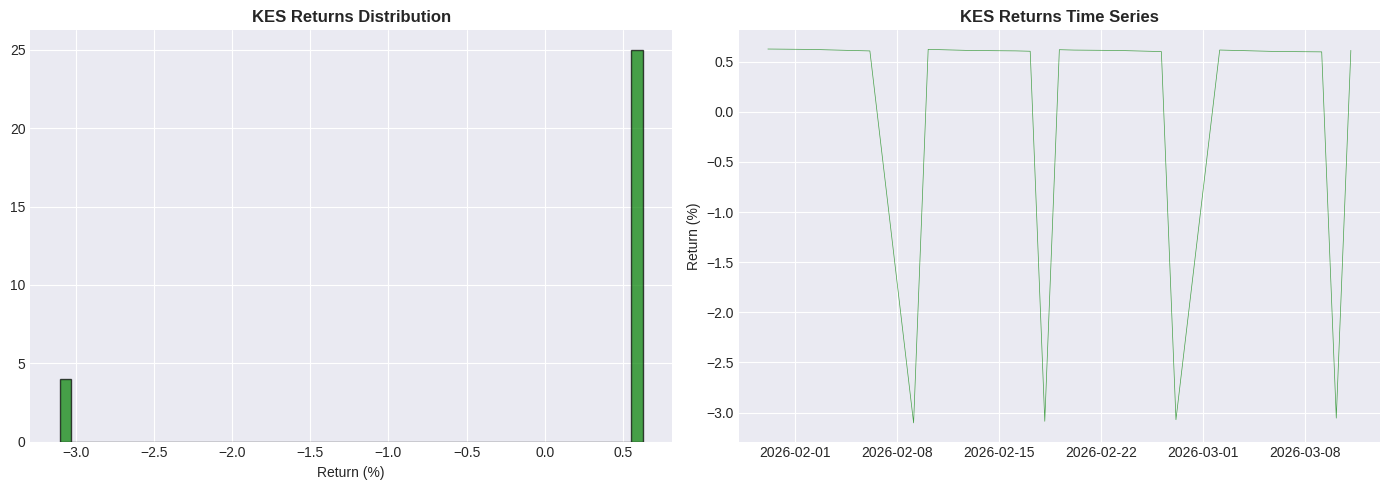

Mean return: 0.1028%
Std dev: 1.2954%
Skewness: -2.22


In [9]:
kes_data['date'] = pd.to_datetime(kes_data['date'])
kes_data = kes_data.sort_values('date')
kes_data['returns'] = kes_data['kes_per_usd'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(kes_data['returns'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('KES Returns Distribution', fontweight='bold')
axes[0].set_xlabel('Return (%)')

axes[1].plot(kes_data['date'], kes_data['returns'], color='green', alpha=0.7, linewidth=0.5)
axes[1].set_title('KES Returns Time Series', fontweight='bold')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.savefig('../data/processed/eda_returns.png', dpi=150)
plt.show()

print(f"Mean return: {kes_data['returns'].mean():.4f}%")
print(f"Std dev: {kes_data['returns'].std():.4f}%")
print(f"Skewness: {kes_data['returns'].skew():.2f}")


## 5. Rolling Volatility

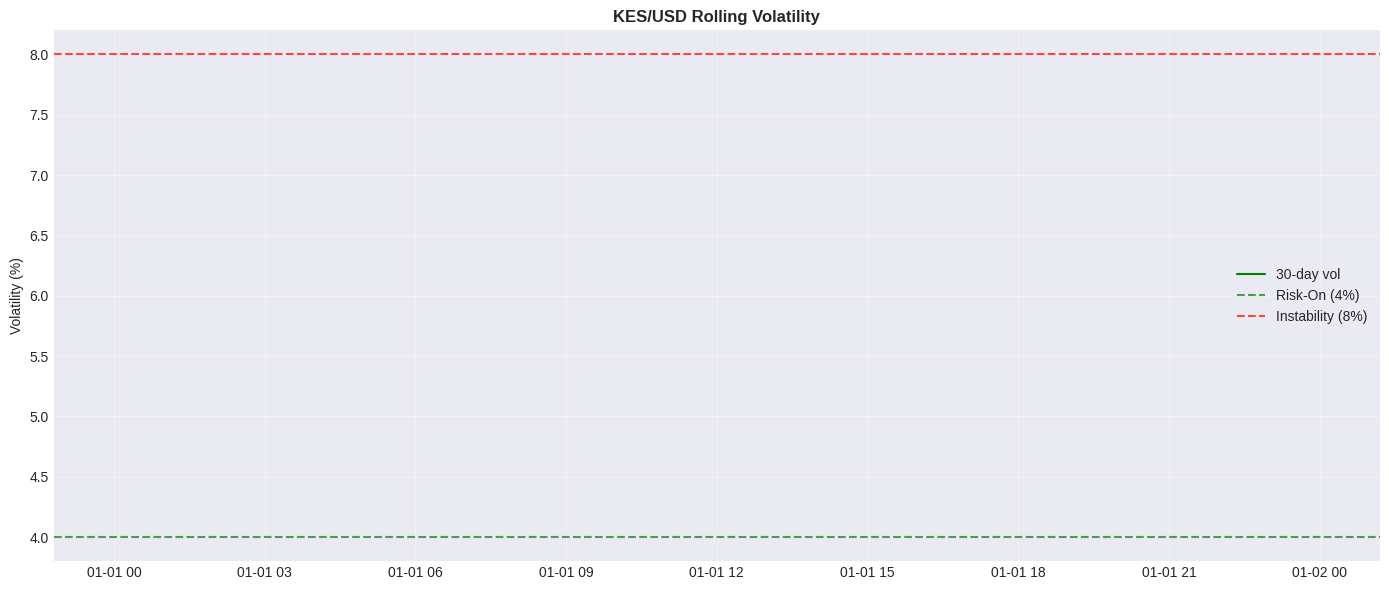

Mean volatility: nan%
Days > 8%: 0
Days < 4%: 0


In [10]:
nairobi_engine = RegimeEngine(MARKETS['nairobi'])

kes_data['vol_30d'] = kes_data['kes_per_usd'].rolling(30).apply(
    lambda x: nairobi_engine.calculate_fx_volatility(x)
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(kes_data['date'], kes_data['vol_30d'] * 100, color='green', label='30-day vol')
ax.axhline(y=4, color='green', linestyle='--', alpha=0.7, label='Risk-On (4%)')
ax.axhline(y=8, color='red', linestyle='--', alpha=0.7, label='Instability (8%)')
ax.fill_between(kes_data['date'], 0, kes_data['vol_30d'] * 100, 
                where=(kes_data['vol_30d'] > 0.08), alpha=0.3, color='red')

ax.set_title('KES/USD Rolling Volatility', fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/eda_volatility.png', dpi=150)
plt.show()

print(f"Mean volatility: {kes_data['vol_30d'].mean() * 100:.2f}%")
print(f"Days > 8%: {(kes_data['vol_30d'] > 0.08).sum()}")
print(f"Days < 4%: {(kes_data['vol_30d'] < 0.04).sum()}")


## 6. Regime Distribution

regime
Unknown    30
Name: count, dtype: int64


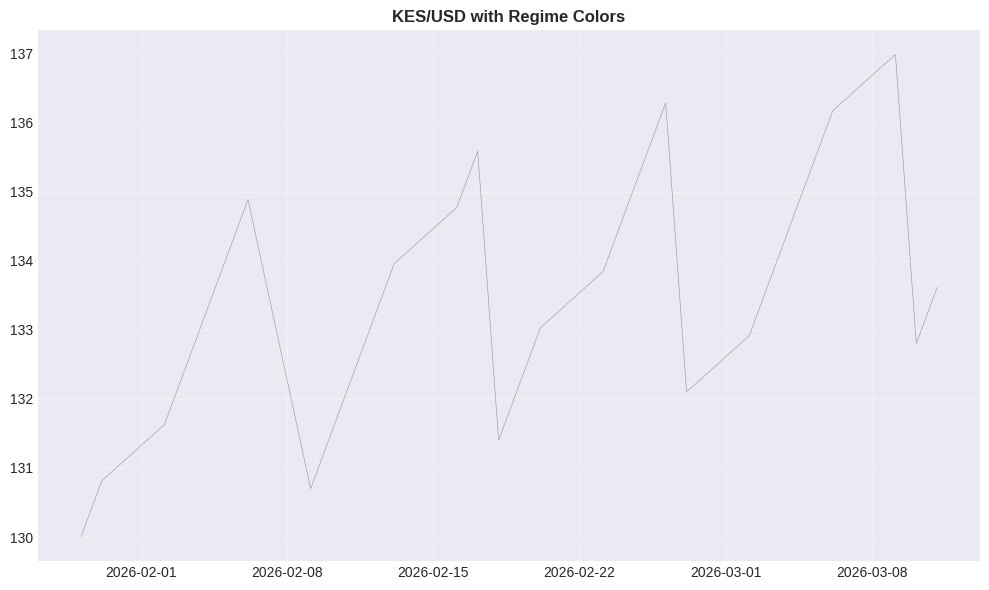

In [11]:
def classify(vol):
    if pd.isna(vol):
        return 'Unknown'
    elif vol < 0.04:
        return 'Risk-On'
    elif vol > 0.08:
        return 'Instability'
    else:
        return 'Defensive'

kes_data['regime'] = kes_data['vol_30d'].apply(classify)
print(kes_data['regime'].value_counts())

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Risk-On': '#2ecc71', 'Defensive': '#f39c12', 'Instability': '#e74c3c'}

for regime in colors:
    mask = kes_data['regime'] == regime
    if mask.any():
        ax.scatter(kes_data.loc[mask, 'date'], kes_data.loc[mask, 'kes_per_usd'],
                  c=colors[regime], label=regime, s=5, alpha=0.6)

ax.plot(kes_data['date'], kes_data['kes_per_usd'], 'k-', alpha=0.3, linewidth=0.5)
ax.set_title('KES/USD with Regime Colors', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/eda_regimes.png', dpi=150)
plt.show()


## 7. Export Summary

In [12]:
kes_data.to_csv('../data/processed/kenya_eda.csv', index=False)

mean_ret = kes_data['returns'].mean()
std_ret = kes_data['returns'].std()
skew_ret = kes_data['returns'].skew()
mean_vol = kes_data['vol_30d'].mean() * 100
instability_days = (kes_data['vol_30d'] > 0.08).sum()
riskon_days = (kes_data['vol_30d'] < 0.04).sum()

# Build summary string using format method instead of f-string
summary_lines = [
    "# EDA Summary",
    "",
    "## KES/USD Statistics",
    f"- Records: {len(kes_data)}",
    f"- Mean return: {mean_ret:.4f}%",
    f"- Volatility: {std_ret:.4f}%",
    f"- Skewness: {skew_ret:.2f}",
    f"- Mean 30-day vol: {mean_vol:.2f}%",
    "",
    "## Regime Distribution",
    kes_data['regime'].value_counts().to_string(),
    "",
    "## Key Findings",
    f"- {instability_days} days in Instability regime",
    f"- {riskon_days} days in Risk-On regime",
]

summary = "\n".join(summary_lines)

with open('../data/logs/eda_summary.md', 'w') as f:
    f.write(summary)

print("Saved: kenya_eda.csv, eda_summary.md")
print("EDA complete!")


Saved: kenya_eda.csv, eda_summary.md
EDA complete!
